In [1]:
import xarray as xr
import faxarray
import os

# Path to a sample file from 2014 dataset
filename = '/mnt/HDS_CLIMATE/CLIMATE/deba/ALARO-RUNS/control/untar-output/pf20140101/pfABOFABOF+0000'

print(f"Attempting to open: {filename}")
print(f"faxarray version: {faxarray.__version__}")




Attempting to open: /mnt/HDS_CLIMATE/CLIMATE/deba/ALARO-RUNS/control/untar-output/pf20140101/pfABOFABOF+0000
faxarray version: 0.2.4


In [ ]:
ds=xr.open_dataset(filename)



ecTrans at version: 1.6.0
commit: 2c4c818d79effe56d30bb2896866aba590a5fad8



<xarray.Dataset> Size: 6GB
Dimensions:           (time: 1, level: 87, y: 480, x: 480, pressure: 6)
Coordinates:
  * time              (time) datetime64[us] 8B 2014-01-01
  * level             (level) int32 348B 0 1 2 3 4 5 6 ... 80 81 82 83 84 85 86
    lat               (y, x) float64 2MB ...
    lon               (y, x) float64 2MB ...
  * pressure          (pressure) int32 24B 0 1 2 3 4 5
Dimensions without coordinates: y, x
Data variables: (12/191)
    WIND_U_PHYS       (time, level, y, x) float64 160MB ...
    WIND_V_PHYS       (time, level, y, x) float64 160MB ...
    TEMPERATURE       (time, level, y, x) float64 160MB ...
    HUMI_SPECIFI      (time, level, y, x) float64 160MB ...
    GEOPOTENTIEL      (time, level, y, x) float64 160MB ...
    SIM_REFLECTI      (time, level, y, x) float64 160MB ...
    ...                ...
    KT273PSHI_CONV_C  (time, y, x) float64 2MB ...
    KT273TOTAL_TUR_E  (time, y, x) float64 2MB ...
    KT273SHEAR TERM   (time, y, x) float64 2MB ...
    KT273Q SRC TERM   (time, y, x) float64 2MB ...
    KT273S SRC TERM   (time, y, x) float64 2MB ...
    KT273RK_QCTEND    (time, y, x) float64 2MB ...
Attributes:
    source:         /mnt/HDS_CLIMATE/CLIMATE/deba/ALARO-RUNS/control/untar-ou...
    Conventions:    CF-1.8
    base_time:      2014-01-01T00:00:00.000000
    lead_time:      0 microseconds
    institution:    Météo-France
    source_format:  FA

In [7]:
print(ds)

<xarray.Dataset> Size: 6GB
Dimensions:           (time: 1, level: 87, y: 480, x: 480, pressure: 6)
Coordinates:
  * time              (time) datetime64[us] 8B 2014-01-01
  * level             (level) int32 348B 0 1 2 3 4 5 6 ... 80 81 82 83 84 85 86
    lat               (y, x) float64 2MB ...
    lon               (y, x) float64 2MB ...
  * pressure          (pressure) int32 24B 0 1 2 3 4 5
Dimensions without coordinates: y, x
Data variables: (12/191)
    WIND_U_PHYS       (time, level, y, x) float64 160MB ...
    WIND_V_PHYS       (time, level, y, x) float64 160MB ...
    TEMPERATURE       (time, level, y, x) float64 160MB ...
    HUMI_SPECIFI      (time, level, y, x) float64 160MB ...
    GEOPOTENTIEL      (time, level, y, x) float64 160MB ...
    SIM_REFLECTI      (time, level, y, x) float64 160MB ...
    ...                ...
    KT273PSHI_CONV_C  (time, y, x) float64 2MB ...
    KT273TOTAL_TUR_E  (time, y, x) float64 2MB ...
    KT273SHEAR TERM   (time, y, x) float64 2MB ...
   

In [2]:
dx = xr.open_dataset(
    filename,
    engine="faxarray",
    variables=["WIND_U_PHYS"]   # only what you need
)



ecTrans at version: 1.6.0
commit: 2c4c818d79effe56d30bb2896866aba590a5fad8



In [3]:
temp = xr.open_dataset(
    filename,
    engine="faxarray",
    variables=["SURFTEMPERATURE"]   # only what you need
)

<Axes: title={'center': 'SURFTEMPERATURE'}, xlabel='Longitude', ylabel='Latitude'>

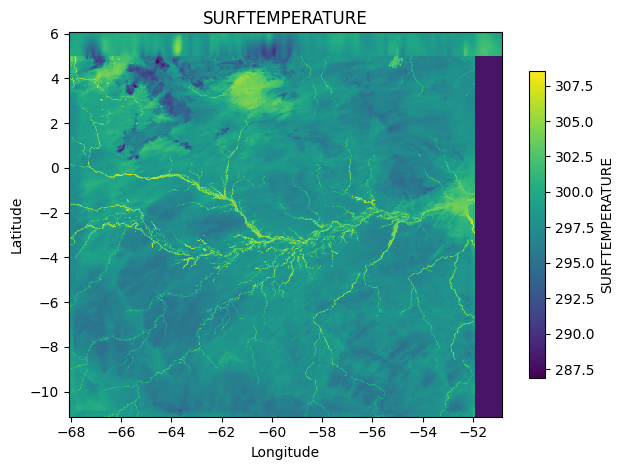

In [5]:
temp.SURFTEMPERATURE.fa.plot()

<Axes: title={'center': 'SURFTEMPERATURE'}, xlabel='Longitude', ylabel='Latitude'>

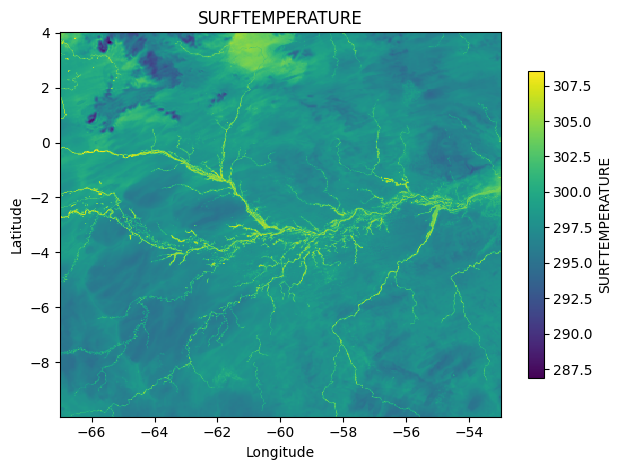

In [8]:
mask = (
    (temp.lon >= -67) & (temp.lon <= -53) &
    (temp.lat >= -10) & (temp.lat <= 4)
)
roi = temp.where(mask, drop=True)

roi["SURFTEMPERATURE"].isel(time=0).fa.plot()
